# Sanad Naqvi || 221A023 || 29

In [47]:
print("Sanad Naqvi || 221A023")

import numpy as np
import matplotlib.pyplot as plt

Sanad Naqvi || 221A023


In [48]:
print("Sanad Naqvi || 221A023")

class MultiArmedBandit:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)
        self.best_arm = np.argmax(self.q_true)

    def pull_arm(self, arm):
        return np.random.normal(self.q_true[arm], 1)


Sanad Naqvi || 221A023


In [55]:
print("Sanad Naqvi || 221A023")
class Agent:
    def __init__(self, bandit, strategy="epsilon_greedy", epsilon=0.1, c=2):
        self.bandit = bandit
        self.strategy = strategy
        self.epsilon = epsilon
        self.c = c
        self.k = bandit.k
        self.Q = np.zeros(self.k) # Estimated rewards
        self.N = np.zeros(self.k) # Number of times each arm was pulled

    def select_action(self, t):
        if self.strategy == "epsilon_greedy":
           if np.random.rand() < self.epsilon:
              return np.random.randint(self.k) # Random action
           return np.argmax(self.Q) # Exploit best-known action
        elif self.strategy == "ucb1":
           if 0 in self.N: # Ensure all arms are tried at least once
               return np.argmin(self.N)
           return np.argmax(self.Q + self.c * np.sqrt(np.log(t + 1) / self.N))


    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]

Sanad Naqvi || 221A023


In [56]:
print("Sanad Naqvi || 221A023")
def run_strategy(k=10, steps=1000, runs=200, strategies=["epsilon_greedy", "ucb1"]):
    avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}
    for strategy in strategies:
        for run in range(runs):

            bandit = MultiArmedBandit(k)
            agent = Agent(bandit, strategy=strategy)

            rewards = np.zeros(steps)
            for t in range(steps):
                action = agent.select_action(t)
                reward = bandit.pull_arm(action)
                agent.update(action, reward)
                rewards[t] = reward

            avg_rewards[strategy] += rewards / runs
    return avg_rewards

Sanad Naqvi || 221A023


In [57]:
print("Sanad Naqvi || 221A023")
strategies = ["epsilon_greedy", "ucb1"]
results = run_strategy()

Sanad Naqvi || 221A023


In [58]:
print("Sanad Naqvi || 221A023")
results.keys()

Sanad Naqvi || 221A023


dict_keys(['epsilon_greedy', 'ucb1'])

Sanad Naqvi || 221A023


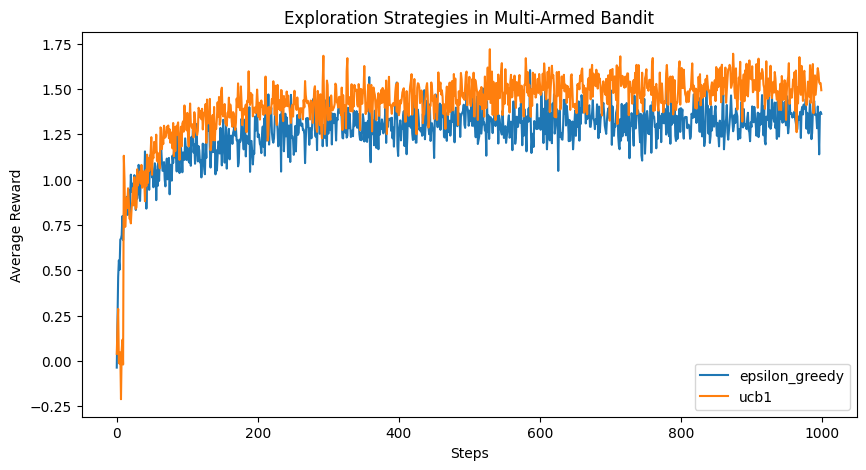

In [61]:
print("Sanad Naqvi || 221A023")
plt.figure(figsize=(10, 5))
for strategy, rewards in results.items():
    plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.title("Exploration Strategies in Multi-Armed Bandit")
plt.show()